In [8]:
import torch
import numpy as np
from transformers import ASTForAudioClassification, AutoConfig

# ---------------------------------------------------------
# 1. Configuration & Constants
# ---------------------------------------------------------

# Path to your saved model (usually the checkpoint folder with best metrics)
# e.g., "./ast_delta_z/checkpoint-1900" or just "./ast_delta_z" if you saved the final model there
MODEL_PATH = "/home/rtalwar/robot-imitation-glue/ast_delta_z/checkpoint-340" 

# MUST match the values printed during training
TRAIN_MEAN = 0.6198999470846517
TRAIN_STD  = 0.06112271215561439

# Define labels (Update these to match your actual classes)
ID2LABEL = {
    0: "Class_0",
    1: "Class_1"
}

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Inference running on: {device}")


# ---------------------------------------------------------
# 2. Load Model
# ---------------------------------------------------------

# The config saved in MODEL_PATH already contains the customized 
# max_length (298) and architecture changes.
model = ASTForAudioClassification.from_pretrained(MODEL_PATH)
model.to(device)
model.eval() # Set to evaluation mode (freezes Dropout, Batchnorm, etc.)

print("Model loaded successfully.")


# ---------------------------------------------------------
# 3. Preprocessing Function
# ---------------------------------------------------------

def preprocess_spectrogram(spectrogram_array):
    """
    Prepares a raw numpy spectrogram for the AST model.
    Expected Input Shape: (Time, Freq) -> e.g., (298, 128)
    """
    # 1. Convert to numpy if not already
    spec = np.array(spectrogram_array, dtype=np.float32)

    # 2. Apply the EXACT same normalization as training
    # norm(x) = (x - mean) / (std * 2)
    spec_normalized = (spec - TRAIN_MEAN) / (TRAIN_STD * 2)

    # 3. Convert to PyTorch Tensor
    tensor = torch.tensor(spec_normalized)

    # 4. Add Batch Dimension if missing: (298, 128) -> (1, 298, 128)
    if tensor.ndim == 2:
        tensor = tensor.unsqueeze(0)
        
    return tensor.to(device)



Inference running on: cuda
Model loaded successfully.


In [9]:
dummy_input = np.random.random((1,298, 128))
dummy_tensor = preprocess_spectrogram(dummy_input)
print(f"Preprocessed dummy input shape: {dummy_tensor.shape}")  # Should be (1, 298, 128)
model(dummy_tensor)  # Test a forward pass to ensure everything is working

Preprocessed dummy input shape: torch.Size([1, 298, 128])


SequenceClassifierOutput(loss=None, logits=tensor([[-0.7189, -0.6325]], device='cuda:0', grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [10]:
from robot_imitation_glue.uR3station.robot_env import UR3eStation
import matplotlib.pyplot as plt
if __name__ == "__main__":

    # env = UR3eStation(with_instrumentation=True)
    obs=env.get_observations()
    spectogram = obs["spectogram_values"][:,:,0]


    # ---------------------------------------------------------
    # 4. Inference
    # ---------------------------------------------------------

    # EXAMPLE: Let's create a dummy spectrogram to test
    # In reality, you would load this from a file or your dataset
    # Shape must match what you trained on: (298 time frames, 128 freq bins)
    dummy_input = spectogram
    plt.imshow(dummy_input)
    # Preprocess
    inputs = preprocess_spectrogram(dummy_input)

    # Prediction
    with torch.no_grad():
        # Pass input_values specifically (AST expects this argument name)
        print(inputs.shape)
        outputs = model(input_values=inputs)
        
        # Get Logits
        logits = outputs.logits
        
        # Convert to Probabilities (Softmax)
        probs = torch.nn.functional.softmax(logits, dim=-1)
        
        # Get Predicted Class
        pred_idx = torch.argmax(probs, dim=-1).item()
        confidence = probs[0, pred_idx].item()

    # ---------------------------------------------------------
    # 5. Output Results
    # ---------------------------------------------------------

    print("\n--- Inference Results ---")
    print(f"Raw Logits: {logits.cpu().numpy()}")
    print(f"Probabilities: {probs.cpu().numpy()}")
    print(f"Predicted Class Index: {pred_idx}")
    print(f"Predicted Label: {ID2LABEL[pred_idx]}")
    print(f"Confidence: {confidence:.4f}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


NameError: name 'env' is not defined

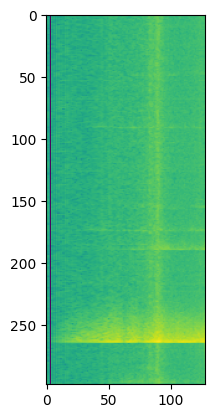

1765797375.427742 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797375.427970 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797375.428269 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797375.493881 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797375.494159 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797375.494354 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797375.563399 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797375.563640 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797375.563800 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797375.628923 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1


Reconnecting...


1765797378.030583 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797378.030838 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797378.031075 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797378.096049 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797378.096351 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797378.096635 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797378.101316 [0]        tev: ddsi_udp_conn_write to udp/239.255.0.1:7400 failed with retcode -1
1765797378.163911 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797378.164206 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1
1765797378.164612 [0]     python: ddsi_udp_conn_write to udp/10.42.0.1:50531 failed with retcode -1

In [ ]:
dummy_input = spectogram[::-1] #niet nodig
plt.imshow(dummy_input)

In [12]:
from transformers import ASTModel
from transformers import ASTForAudioClassification, AutoConfig


hf_config = AutoConfig.from_pretrained("ramen-noodels/ast_delta_xyz_button_click_detector")
hf_config.max_length = 298

feature_dim = hf_config.hidden_size
backbone = ASTModel.from_pretrained(
"/home/rtalwar/robot-imitation-glue/models/ast_delta_xyz_button_click_detector",
config=hf_config,
ignore_mismatched_sizes=True,  # Rescales positional embeddings for 300-frame spectrograms
)
backbone.to(device)
backbone.eval()

ASTModel(
  (embeddings): ASTEmbeddings(
    (patch_embeddings): ASTPatchEmbeddings(
      (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ASTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ASTLayer(
        (attention): ASTAttention(
          (attention): ASTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ASTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ASTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ASTOutput(
          (d

In [15]:
import numpy as np
dummy_input = np.random.random((1,298, 128))
dummy_tensor = preprocess_spectrogram(dummy_input)
print(f"Preprocessed dummy input shape: {dummy_tensor.shape}")  # Should be (1, 298, 128)
backbone(dummy_tensor).pooler_output.shape  # Test a forward pass to ensure everything is working

Preprocessed dummy input shape: torch.Size([1, 298, 128])


torch.Size([1, 768])